In [1]:
import pynetlogo
import pandas as pd
import itertools
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Explicitly point to the libjvm.dylib file inside NetLogo's application package
# Path on GIS DESKTOP
jvm_path = "C:/Program Files/NetLogo 6.4.0/runtime/bin/server/jvm.dll"
netlogo_home = "C:/Program Files/NetLogo 6.4.0"

#Path on Mac Laptop
#jvm_path = "/Applications/NetLogo 6.4.0/runtime/Contents/Home/lib/server/libjvm.dylib"
#netlogo_home="/Applications/NetLogo 6.4.0"

netlogo = pynetlogo.NetLogoLink(
    gui=False,
    netlogo_home=netlogo_home,
    jvm_path=jvm_path 
)

# Path in GIS DESKTOP
model_path = "C:/Users/15177459/Desktop/Bachelor-Thesis/Netlogo/third_place_attributes.nlogo"

# Path in Mac Laptop
#model_path = "/Users/tonyvo/Desktop/Thesis/netlogo/models/6.4.0/third_place_attributes.nlogo"

netlogo.load_model(model_path)
netlogo.command("setup")

# Experiment 2.1: Preference and Third Place Attributes

In [2]:
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [30],
    "third-place-search-radius": [2],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [5],
    "social-feedback?": [True],
    "attribute-based-choice?": [False, True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

exp2 = pd.DataFrame(results)

print(exp2.shape)
exp2.head()

(40, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,30,2,50,30,45,60,...,30.680673,6.80,1.5420,4745.0,12.104592,60.0,44.0,0.035714,0.540708,0.509095
1,attribute_test,2,2,200,30,2,50,30,45,60,...,29.815402,5.55,1.5110,4398.0,11.822581,59.0,45.0,0.032258,0.544554,0.552081
2,attribute_test,3,3,200,30,2,50,30,45,60,...,29.983067,5.35,1.4865,4284.0,11.933148,60.0,45.0,0.044568,0.559730,0.499314
3,attribute_test,4,4,200,30,2,50,30,45,60,...,29.577559,5.10,1.4800,4250.0,11.154856,60.0,42.0,0.036745,0.522701,0.504331
4,attribute_test,5,5,200,30,2,50,30,45,60,...,29.992369,6.20,1.5200,4531.0,12.482094,59.0,44.0,0.041322,0.450095,0.544913


In [3]:
off = exp2[exp2["attribute-based-choice?"] == False].iloc[0]
on = exp2[exp2["attribute-based-choice?"] == True].iloc[0]

comparison = pd.DataFrame({
    "metric": [
        "visits-per-person",
        "average-stop-probability",
        "average-social-encounters",
        "average-social-odds-ratio",
        "total-co-presence",
        "co-presence-per-visit",
        "visited-places-count",
        "places-with-co-presence",
        "visit-concentration",
        "average-visited-place-affordability",
        "average-visited-place-welcomingness"
    ],
    "attribute_based_choice_off": [
        off["visits-per-person"],
        off["average-stop-probability"],
        off["average-social-encounters"],
        off["average-social-odds-ratio"],
        off["total-co-presence"],
        off["co-presence-per-visit"],
        off["visited-places-count"],
        off["places-with-co-presence"],
        off["visit-concentration"],
        off["average-visited-place-affordability"],
        off["average-visited-place-welcomingness"]
    ],
    "attribute_based_choice_on": [
        on["visits-per-person"],
        on["average-stop-probability"],
        on["average-social-encounters"],
        on["average-social-odds-ratio"],
        on["total-co-presence"],
        on["co-presence-per-visit"],
        on["visited-places-count"],
        on["places-with-co-presence"],
        on["visit-concentration"],
        on["average-visited-place-affordability"],
        on["average-visited-place-welcomingness"]
    ],
})

comparison["absolute_change"] = comparison["attribute_based_choice_on"] - comparison["attribute_based_choice_off"]
comparison["percent_change"] = (
    comparison["absolute_change"] / comparison["attribute_based_choice_off"] * 100
)

comparison

,metric,attribute_based_choice_off,attribute_based_choice_on,absolute_change,percent_change
0,visits-per-person,1.960000,2.215000,0.255000,13.010204
1,average-stop-probability,30.680673,39.371625,8.690952,28.327124
2,average-social-encounters,6.800000,35.250000,28.450000,418.382353
3,average-social-odds-ratio,1.542000,2.277000,0.735000,47.665370
4,total-co-presence,4745.000000,14684.000000,9939.000000,209.462592
5,co-presence-per-visit,12.104592,33.146727,21.042135,173.835973
6,visited-places-count,60.000000,26.000000,-34.000000,-56.666667
7,places-with-co-presence,44.000000,18.000000,-26.000000,-59.090909
8,visit-concentration,0.035714,0.119639,0.083925,234.988713
9,average-visited-place-affordability,0.540708,0.715495,0.174787,32.325536


# Experiemnt 2.2.1: Connectivity vs Time Pressure

Compare directly Path A vs Path B. Attribute: Off

In [16]:
# Attribute based choice OFF
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [10, 20, 30, 40],
    "third-place-search-radius": [1, 2, 5, 10],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [5],
    "social-feedback?": [True],
    "attribute-based-choice?": [False]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

exp2 = pd.DataFrame(results)

print(exp2.shape)
exp2.head()

(320, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,10,1,50,30,45,60,...,8.164985,1.40,1.127,1360.0,7.861272,53.0,17.0,0.075145,0.526451,0.508183
1,attribute_test,2,2,200,10,1,50,30,45,60,...,7.455531,0.50,1.050,444.0,3.288889,52.0,9.0,0.051852,0.540221,0.555844
2,attribute_test,3,3,200,10,1,50,30,45,60,...,7.750495,0.65,1.065,592.0,4.000000,55.0,9.0,0.047297,0.572607,0.496510
3,attribute_test,4,4,200,10,1,50,30,45,60,...,8.310739,1.90,1.176,1456.0,7.786096,54.0,19.0,0.080214,0.532022,0.504955
4,attribute_test,5,5,200,10,1,50,30,45,60,...,8.107470,1.45,1.145,1095.0,6.676829,53.0,21.0,0.048780,0.452280,0.524163


In [17]:
grouped = exp2.groupby(["baseline-stop-probability", "third-place-search-radius"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped

,baseline-stop-probability,third-place-search-radius,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,1,850.70,298.499952,0.77600,0.9975,0.062179,5.370732
1,10,2,719.45,378.917360,0.67950,0.7850,0.051769,5.077151
2,10,5,612.40,208.197882,0.65700,0.7250,0.048653,4.605957
3,10,10,517.25,231.728488,0.62575,0.6075,0.049574,4.096532
4,20,1,2996.35,672.038084,1.44875,3.8575,0.057642,10.258324
5,20,2,2295.15,503.363139,1.30425,2.7400,0.040120,8.748781
6,20,5,1680.55,327.523318,1.15925,1.9875,0.039793,7.204622
7,20,10,1694.70,395.115053,1.13850,2.0600,0.038420,7.381475
8,30,1,5403.10,1158.510200,2.07900,7.3250,0.049625,12.886893
9,30,2,4399.20,836.157792,1.84600,5.7175,0.037215,11.856695


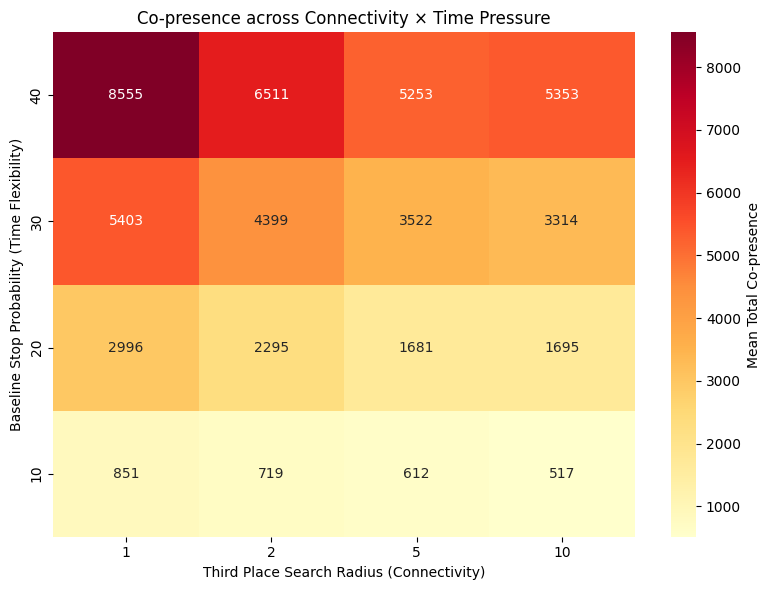

In [18]:
pivot = grouped.pivot(
    index="baseline-stop-probability",
    columns="third-place-search-radius",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Co-presence across Connectivity × Time Pressure")
ax.set_xlabel("Third Place Search Radius (Connectivity)")
ax.set_ylabel("Baseline Stop Probability (Time Flexibility)")
plt.tight_layout()


In [19]:
path_a = grouped[
    (grouped["baseline-stop-probability"] == 40) &
    (grouped["third-place-search-radius"] == 1)
]["co_presence_mean"].values[0]

path_b = grouped[
    (grouped["baseline-stop-probability"] == 10) &
    (grouped["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Path A (low connectivity, high flexibility): {path_a:.1f}")
print(f"Path B (high connectivity, high time pressure): {path_b:.1f}")
print(f"Difference: {path_a - path_b:.1f}")


Path A (low connectivity, high flexibility): 8555.4
Path B (high connectivity, high time pressure): 517.2
Difference: 8038.1


In [20]:
baseline = grouped[
    (grouped["baseline-stop-probability"] == 30) &
    (grouped["third-place-search-radius"] == 2)
]["co_presence_mean"].values[0]  # your original fixed condition

dispersal_only = grouped[
    (grouped["baseline-stop-probability"] == 30) &  # pressure held constant
    (grouped["third-place-search-radius"] == 10)    # only radius increases
]["co_presence_mean"].values[0]

pressure_only = grouped[
    (grouped["baseline-stop-probability"] == 10) &  # only pressure increases
    (grouped["third-place-search-radius"] == 2)     # radius held constant
]["co_presence_mean"].values[0]

combined = grouped[
    (grouped["baseline-stop-probability"] == 10) &
    (grouped["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Baseline: {baseline:.1f}")
print(f"Dispersal effect alone: {dispersal_only - baseline:.1f}")
print(f"Time pressure effect alone: {pressure_only - baseline:.1f}")
print(f"Combined effect: {combined-baseline:.1f}")



Baseline: 4399.2
Dispersal effect alone: -1085.4
Time pressure effect alone: -3679.8
Combined effect: -3881.9


# Experiemnt 2.2.2: Connectivity vs Time Pressure

Compare directly Path A vs Path B. Attribute: On

In [ ]:
# Attribute based choice ON
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [10, 20, 30, 40],
    "third-place-search-radius": [1, 2, 5, 10],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [5],
    "social-feedback?": [True],
    "attribute-based-choice?": [True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

exp2_2 = pd.DataFrame(results)

print(exp2_2.shape)
exp2_2.head()

(320, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,10,1,50,30,45,60,...,8.983445,3.25,1.2560,2247.0,13.140351,36.0,15.0,0.122807,0.592335,0.677218
1,attribute_test,2,2,200,10,1,50,30,45,60,...,8.564894,2.45,1.2190,1832.0,11.819355,39.0,14.0,0.083871,0.619892,0.654527
2,attribute_test,3,3,200,10,1,50,30,45,60,...,8.994830,2.55,1.2495,2276.0,14.875817,34.0,13.0,0.098039,0.650876,0.605243
3,attribute_test,4,4,200,10,1,50,30,45,60,...,8.667442,2.60,1.2270,2281.0,13.658683,33.0,16.0,0.083832,0.624168,0.615319
4,attribute_test,5,5,200,10,1,50,30,45,60,...,8.651313,2.90,1.2285,2337.0,13.994012,34.0,14.0,0.107784,0.546683,0.588554


In [ ]:
grouped2 = exp2_2.groupby(["baseline-stop-probability", "third-place-search-radius"]).agg(
    co_presence_mean = ("total-co-presence", "mean"),
    co_presence_std = ("total-co-presence", "std"),
    visits_mean = ("visits-per-person", "mean"),
    encounter_mean = ("average-social-encounters", "mean"),
    concentration_mean = ("visit-concentration", "mean"),
    copresence_per_visit_mean = ("co-presence-per-visit", "mean")
).reset_index()

grouped

,baseline-stop-probability,third-place-search-radius,co_presence_mean,co_presence_std,visits_mean,encounter_mean,concentration_mean,copresence_per_visit_mean
0,10,1,1797.75,423.285132,0.76350,2.3275,0.095442,11.690120
1,10,2,2887.70,754.079229,0.75750,4.4250,0.149964,18.876633
2,10,5,3931.20,898.218154,0.70625,7.2150,0.217125,27.541046
3,10,10,3916.05,871.859143,0.70500,7.1425,0.216182,27.514576
4,20,1,6032.45,769.370110,1.53950,9.6675,0.089077,19.555364
5,20,2,8725.20,1182.050475,1.47050,18.4800,0.153584,29.618426
6,20,5,10221.85,1231.702941,1.36875,28.7825,0.208248,37.262307
7,20,10,10303.50,1445.408429,1.34850,29.0250,0.218150,38.053014
8,30,1,10807.85,1488.441901,2.20900,20.2475,0.089104,24.398507
9,30,2,13600.05,1220.242188,2.06425,36.1950,0.149977,32.913811


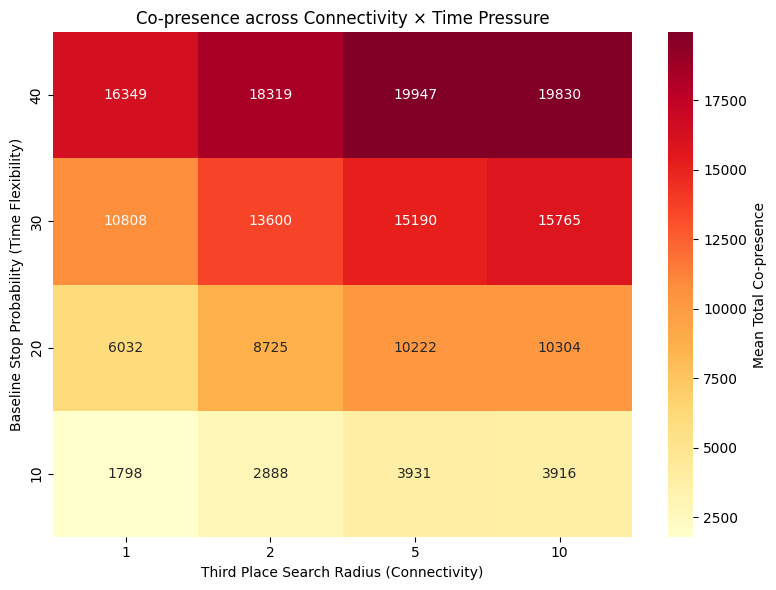

In [ ]:
pivot = grouped2.pivot(
    index="baseline-stop-probability",
    columns="third-place-search-radius",
    values="co_presence_mean"
)

# Flip so high stop probability is at top (more intuitive reading)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlOrRd",
    ax=ax,
    cbar_kws={"label": "Mean Total Co-presence"}
)
ax.set_title("Co-presence across Connectivity × Time Pressure (Attributes = On)")
ax.set_xlabel("Third Place Search Radius (Connectivity)")
ax.set_ylabel("Baseline Stop Probability (Time Flexibility)")
plt.tight_layout()


In [ ]:
path_a = grouped2[
    (grouped2["baseline-stop-probability"] == 40) &
    (grouped2["third-place-search-radius"] == 1)
]["co_presence_mean"].values[0]

path_b = grouped2[
    (grouped2["baseline-stop-probability"] == 10) &
    (grouped2["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Path A (low connectivity, high flexibility): {path_a:.1f}")
print(f"Path B (high connectivity, high time pressure): {path_b:.1f}")
print(f"Difference: {path_a - path_b:.1f}")


Path A (low connectivity, high flexibility): 16348.7
Path B (high connectivity, high time pressure): 3916.1
Difference: 12432.7


In [ ]:
baseline = grouped2[
    (grouped2["baseline-stop-probability"] == 30) &
    (grouped2["third-place-search-radius"] == 2)
]["co_presence_mean"].values[0]  # your original fixed condition

dispersal_only = grouped2[
    (grouped2["baseline-stop-probability"] == 30) &  # pressure held constant
    (grouped2["third-place-search-radius"] == 10)    # only radius increases
]["co_presence_mean"].values[0]

pressure_only = grouped2[
    (grouped2["baseline-stop-probability"] == 10) &  # only pressure increases
    (grouped["third-place-search-radius"] == 2)     # radius held constant
]["co_presence_mean"].values[0]

combined = grouped2[
    (grouped2["baseline-stop-probability"] == 10) &
    (grouped2["third-place-search-radius"] == 10)
]["co_presence_mean"].values[0]

print(f"Baseline: {baseline:.1f}")
print(f"Dispersal effect alone: {dispersal_only - baseline:.1f}")
print(f"Time pressure effect alone: {pressure_only - baseline:.1f}")
print(f"Combined effect: {combined-baseline:.1f}")


Baseline: 13600.0
Dispersal effect alone: 2164.5
Time pressure effect alone: -10712.3
Combined effect: -9684.0


# Experiment 2.3: Social Interactions and Encounter weight

Attributes concentrate people into a smaller subset of third places. But what level of social interaction is needed for that concentration to become self-reinforcing co-presence? Basically what is the critical value of encounter weight

In [21]:
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [30],
    "third-place-search-radius": [5],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-odds-increment": [0.10],
    "encounter-weight": [0, 0.5, 1, 2, 3, 5, 7.5, 10],
    "social-feedback?": [True],
    "attribute-based-choice?": [True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

exp3 = pd.DataFrame(results)

print(exp3.shape)
exp3.head()

(160, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,30,5,50,30,45,60,...,23.173982,0.0,1.0,12732.0,40.419048,12.0,8.0,0.200000,0.813698,0.772560
1,attribute_test,2,2,200,30,5,50,30,45,60,...,22.686215,0.0,1.0,11324.0,39.183391,9.0,7.0,0.245675,0.894414,0.889263
2,attribute_test,3,3,200,30,5,50,30,45,60,...,23.171624,0.0,1.0,13824.0,42.275229,10.0,8.0,0.232416,0.837978,0.737037
3,attribute_test,4,4,200,30,5,50,30,45,60,...,22.844683,0.0,1.0,12943.0,40.958861,9.0,6.0,0.202532,0.760534,0.896376
4,attribute_test,5,5,200,30,5,50,30,45,60,...,22.816207,0.0,1.0,11929.0,36.480122,12.0,12.0,0.214067,0.761390,0.810322


In [24]:
exp3_table = (
    exp3.groupby("encounter-weight")
    [[
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration"
]]
    .mean()
    .reset_index()
)

exp3_table

,encounter-weight,visits-per-person,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration
0,0.0,1.55550,22.803629,0.00000,1.000000,11907.15,38.251077,11.50,8.95,0.206975
1,0.5,1.64400,28.961345,4.08425,1.406300,12755.30,38.740606,11.60,9.05,0.204300
2,1.0,1.75675,33.928177,9.35800,1.819500,13864.55,39.384272,11.40,8.85,0.207947
3,2.0,1.84725,37.888572,21.29900,2.181600,14791.85,39.993496,11.25,8.65,0.210266
4,3.0,1.88025,38.983342,33.09000,2.288275,15079.00,40.063477,11.30,8.75,0.206852
5,5.0,1.89800,39.610979,55.82000,2.350125,15189.55,40.002429,11.20,8.55,0.208659
6,7.5,1.91950,39.856500,85.89750,2.371750,15440.70,40.196344,11.55,8.55,0.202942
7,10.0,1.94275,40.185802,117.08500,2.400850,15605.45,40.125698,11.30,8.55,0.204583


So going from 0 to 3 creates a big increase:

11,907 → 15,079

That is an increase of about 3,172 co-presence units.

But going from 3 to 10 only adds:

15,079 → 15,605

That is only about 526 more.

So the model suggests that social feedback has diminishing returns.

The critical value seems to be around 2–3

# Experiment 2.4: Encounter odds increment


In [26]:
parameter_grid = {
    "number-of-people": [200],
    "baseline-stop-probability": [30],
    "third-place-search-radius": [5],
    "route-third-place-sample-size": [50],
    "rigid-dwell-time": [30],
    "medium-dwell-time": [45],
    "flexible-dwell-time": [60],
    "encounter-weight": [3],
    "encounter-odds-increment": [0, 0.01, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.30, 0.50],
    "social-feedback?": [True],
    "attribute-based-choice?": [True]
}

reporters = [
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration",
    "average-visited-place-affordability",
    "average-visited-place-welcomingness"
]

results = []

keys = list(parameter_grid.keys())
values = list(parameter_grid.values())

run_id = 0

for combination in itertools.product(*values):
    params = dict(zip(keys, combination))
    
    for seed in range(1, 21):  # 20 repetitions
        run_id += 1
        
        netlogo.command(f"random-seed {seed}")
        
        for parameter, value in params.items():
            if isinstance(value, bool):
                value = "true" if value else "false"
            netlogo.command(f"set {parameter} {value}")
        
        netlogo.command("setup")
        netlogo.command("repeat 1000 [ go ]")
        
        row = {
            "experiment": "attribute_test",
            "run_id": run_id,
            "seed": seed,
            **params,
        }
        
        for reporter in reporters:
            row[reporter] = netlogo.report(reporter)
        
        results.append(row)

exp4 = pd.DataFrame(results)

print(exp4.shape)
exp4.head()

(200, 25)


,experiment,run_id,seed,number-of-people,baseline-stop-probability,third-place-search-radius,route-third-place-sample-size,rigid-dwell-time,medium-dwell-time,flexible-dwell-time,...,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration,average-visited-place-affordability,average-visited-place-welcomingness
0,attribute_test,1,1,200,30,5,50,30,45,60,...,23.173982,22.74,1.0,12732.0,40.419048,12.0,8.0,0.200000,0.813698,0.772560
1,attribute_test,2,2,200,30,5,50,30,45,60,...,22.686215,21.57,1.0,11324.0,39.183391,9.0,7.0,0.245675,0.894414,0.889263
2,attribute_test,3,3,200,30,5,50,30,45,60,...,23.171624,27.42,1.0,13824.0,42.275229,10.0,8.0,0.232416,0.837978,0.737037
3,attribute_test,4,4,200,30,5,50,30,45,60,...,22.844683,26.88,1.0,12943.0,40.958861,9.0,6.0,0.202532,0.760534,0.896376
4,attribute_test,5,5,200,30,5,50,30,45,60,...,22.816207,20.07,1.0,11929.0,36.480122,12.0,12.0,0.214067,0.761390,0.810322


In [29]:
exp4_table = (
    exp4.groupby("encounter-odds-increment")
    [[
    "visits-per-person",
    "average-stop-probability",
    "average-social-encounters",
    "average-social-odds-ratio",
    "total-co-presence",
    "co-presence-per-visit",
    "visited-places-count",
    "places-with-co-presence",
    "visit-concentration"
]]
    .mean()
    .reset_index()
)

exp4_table

,encounter-odds-increment,visits-per-person,average-stop-probability,average-social-encounters,average-social-odds-ratio,total-co-presence,co-presence-per-visit,visited-places-count,places-with-co-presence,visit-concentration
0,0.000,1.55550,22.803629,21.5970,1.000000,11907.15,38.251077,11.50,8.95,0.206975
1,0.010,1.60500,26.546534,23.0790,1.230790,12325.80,38.354962,11.35,8.70,0.205317
2,0.025,1.71150,31.698959,26.1750,1.626831,13369.00,39.004969,11.40,8.45,0.208650
3,0.050,1.79450,36.348819,29.6940,2.039463,14156.80,39.404805,11.30,8.85,0.210478
4,0.075,1.87500,38.416116,32.2185,2.229400,15013.10,40.007703,11.35,8.45,0.209777
5,0.100,1.88025,38.983342,33.0900,2.288275,15079.00,40.063477,11.30,8.75,0.206852
6,0.150,1.90150,39.627704,33.7920,2.349550,15149.30,39.805683,11.35,8.70,0.206973
7,0.200,1.90700,39.780231,34.0905,2.364400,15306.50,40.105237,11.40,8.60,0.211526
8,0.300,1.93050,40.102439,34.5195,2.393875,15521.00,40.158739,11.30,8.55,0.204045
9,0.500,1.93275,40.114791,34.5180,2.396275,15519.15,40.122980,11.30,8.50,0.206659
